# Model Spikey observed by Kepler with NymPyro+MCMC

In this notebook we use the Bayesian inference package `NumPyro`, using MCMC and NUTS sampler, to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import sys
import copy

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partial
# JAX
import jax
from jax import random
from jax import numpy as jnp
jax.config.update("jax_enable_x64", True)
# NymPyro
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [3]:
# Define global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
c = 'm'

---
## 1. Model light curve ala Hu+2020
---

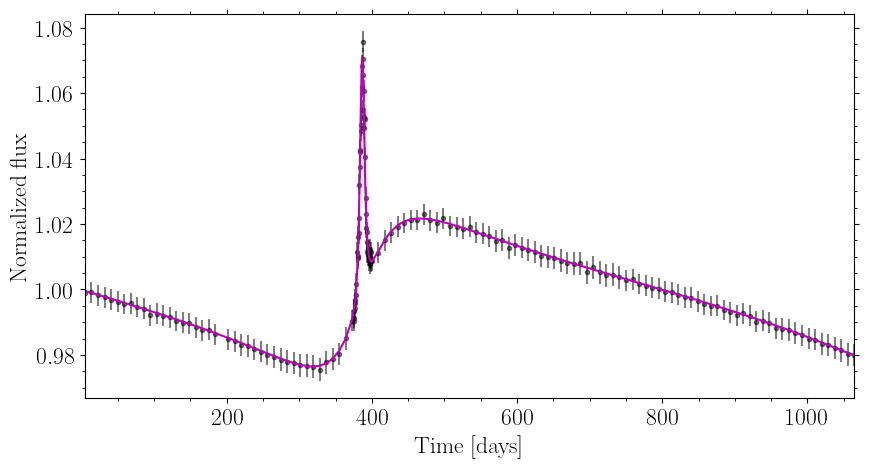

In [4]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_DM_kepler_hu2020.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Normalize light curve to model
df.flux = df.flux * dm.flux.median() / df.flux.median()

# Convert to numpy for modelling
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

# Plot light curve
pt.plot_lc(df, dm, cm=c);

---
### 1.1. Parameterization with `logM1` and `logM2`

In [5]:
names  = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
values = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]

#### *1.1.1. Uniform priors*

In [6]:
filename = 'spikey_kepler_DM_hu2020_logM1logM2_numpyro_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(-3, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(-90, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'L'    : dist.Uniform(0, 1),
    'alpha': dist.Uniform(-4, 4),
    'vz'   : params.vz,
}
#                 mean       std    median      5.0%     95.0%     n_eff     r_hat
#          L      0.47      0.37      0.55      0.02      0.93      2.05      7.84
#          P      1.57      0.93      1.01      0.49      3.03      2.19      4.79
#      alpha      1.00      1.74      0.35     -0.62      3.96      2.04      7.28
#          e      0.93      0.03      0.93      0.87      0.96      2.06      6.55
#          i     34.31     14.19     36.88     11.50     51.40      2.20      3.81
#      logM1      8.72      1.26      8.18      7.10     10.54      2.19      3.41
#      logM2      8.14      1.41      8.43      5.75      9.82      2.16      4.09
#         t0      1.77      0.79      1.53      1.05      2.97      2.00    145.43
#          w    293.05     75.09    319.02    166.55    349.40      2.00     24.70

# Number of divergences: 3078
# CPU times: user 4min 44s, sys: 424 ms, total: 4min 44s
# Wall time: 1min 37s

In [7]:
%%time
# Initialise NUTS kernel
kernel = NUTS(
    bs.make_tinygp_model(priors=priors, build_kernel=None, build_mean=bs.smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Intialise MCMC class
mcmc = MCMC(kernel, num_warmup=1000, num_samples=4000, num_chains=4, progress_bar=True, jit_model_args=True)
# RNG key to reproduce results
rng_key = jax.random.PRNGKey(params.seed)
# Run MCMC analysis
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.47      0.37      0.55      0.02      0.93      2.05      7.84
         P      1.57      0.93      1.01      0.49      3.03      2.19      4.79
     alpha      1.00      1.74      0.35     -0.62      3.96      2.04      7.28
         e      0.93      0.03      0.93      0.87      0.96      2.06      6.55
         i     34.31     14.19     36.88     11.50     51.40      2.20      3.81
     logM1      8.72      1.26      8.18      7.10     10.54      2.19      3.41
     logM2      8.14      1.41      8.43      5.75      9.82      2.16      4.09
        t0      1.77      0.79      1.53      1.05      2.97      2.00    145.43
         w    293.05     75.09    319.02    166.55    349.40      2.00     24.70

Number of divergences: 3078
CPU times: user 4min 44s, sys: 424 ms, total: 4min 44s
Wall time: 1min 37s


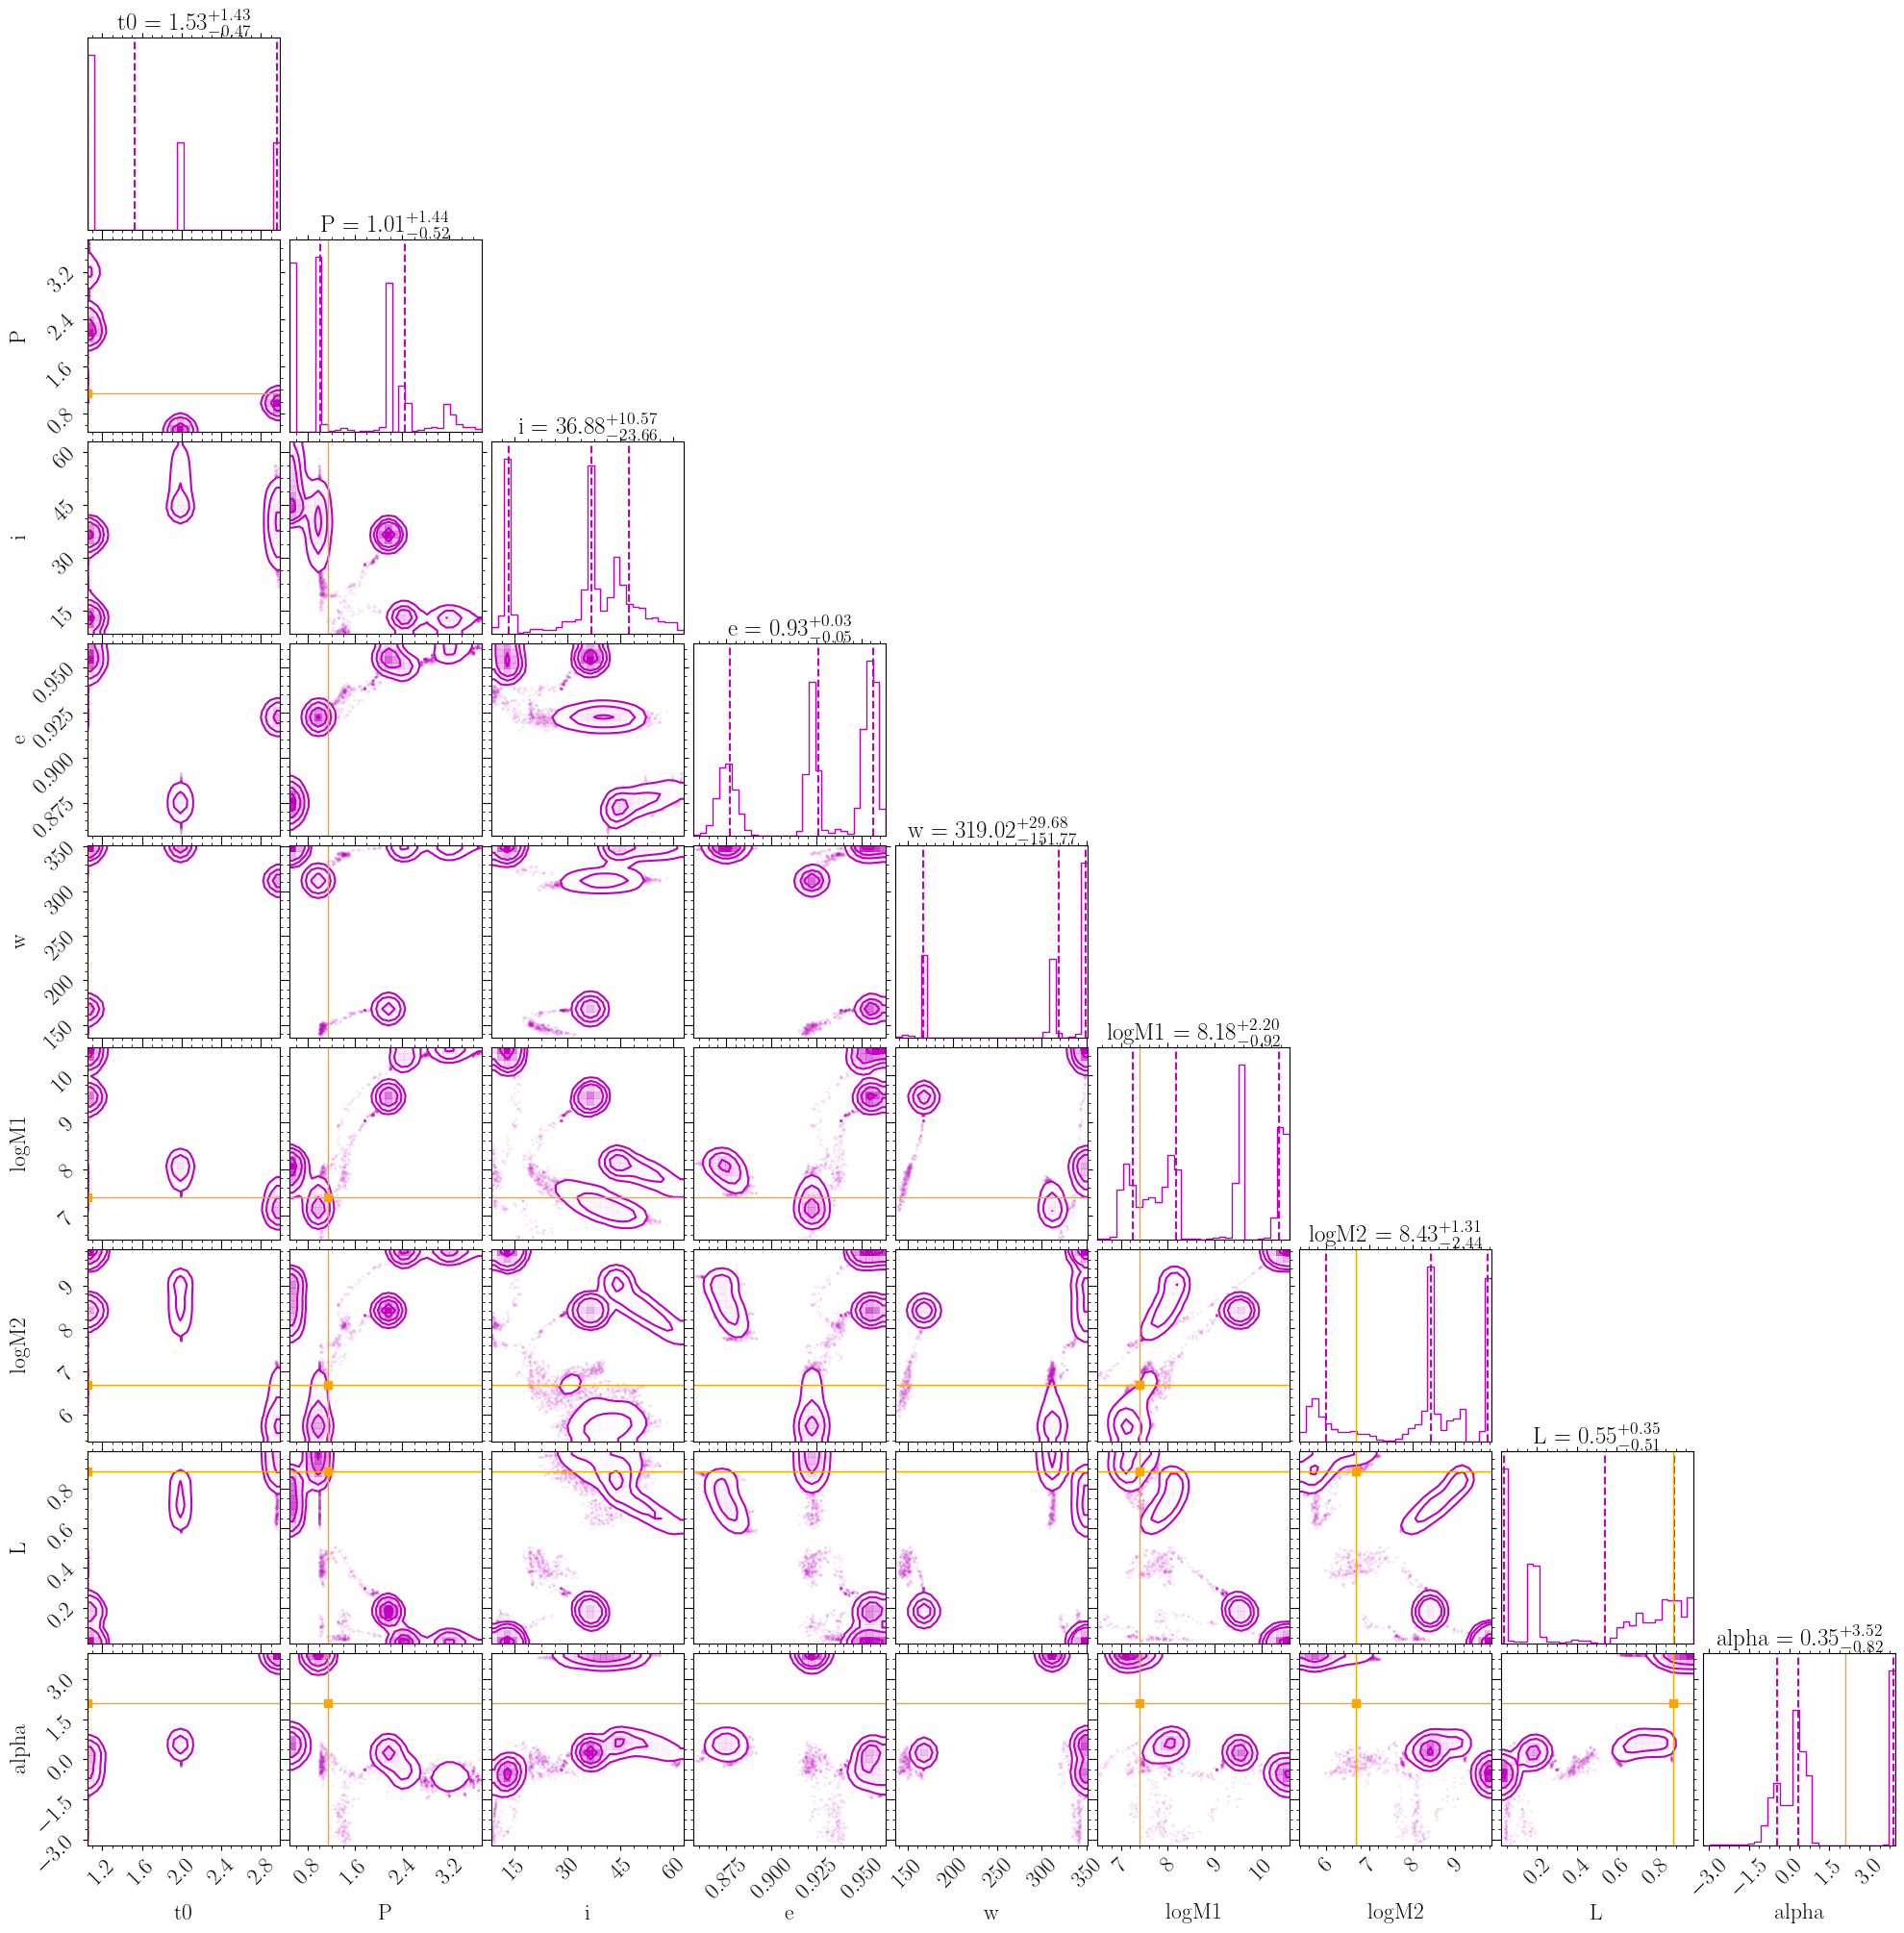

In [8]:
pt.plot_corner_mcmc(samples, names=names, true_params=values, color=c);

In [18]:
# # Create best-fit model and plot along with data
# params_model = copy.deepcopy(params)
# params_model.sigma = 0
# dm = bs.bestfit_model(time, params_model, result)
# fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6));
# # fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

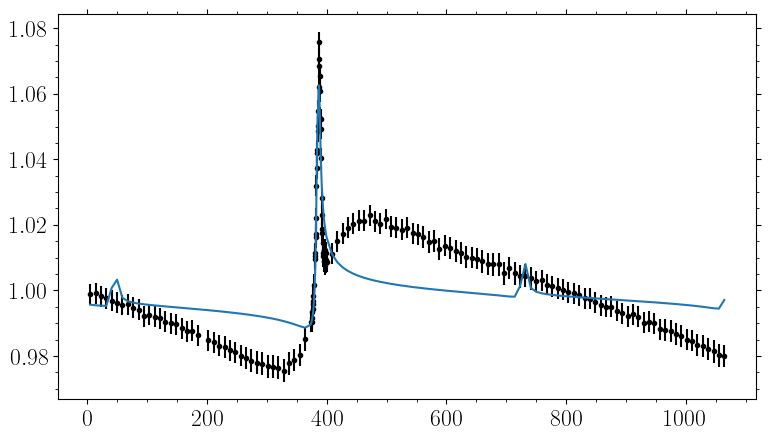

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
# predictive_posterior(ax, x=time, samples=samples)
ax.plot(time, samples['pred_smbhb'].mean(axis=0))

# Let's also plot the mean value
# spikey_params = {
#     'z': params.z, 
#     't0': samples['t0'].mean(), 
#     'P': samples['P'].mean(), 
#     'i': samples['i'].mean(), 
#     'e': samples['e'].mean(), 
#     'w': samples['w'].mean(),
#     'logM1': samples['logM1'].mean(), 
#     'logM2': samples['logM2'].mean(),
#     'L': samples['L'].mean(), 
#     'alpha': samples['alpha'].mean(), 
#     'vz': params.vz, 
#     'mean': 1,
# }

# smbhb_partial = partial(smbhb_jax, **spikey_params)
# sim_flux = jax.vmap(smbhb_partial)(time)
# ax.plot(time, flux);

Something is clearly wrong with the MCMC fitting..

---
## 2. Model 5-d cadence QDM light curve
---

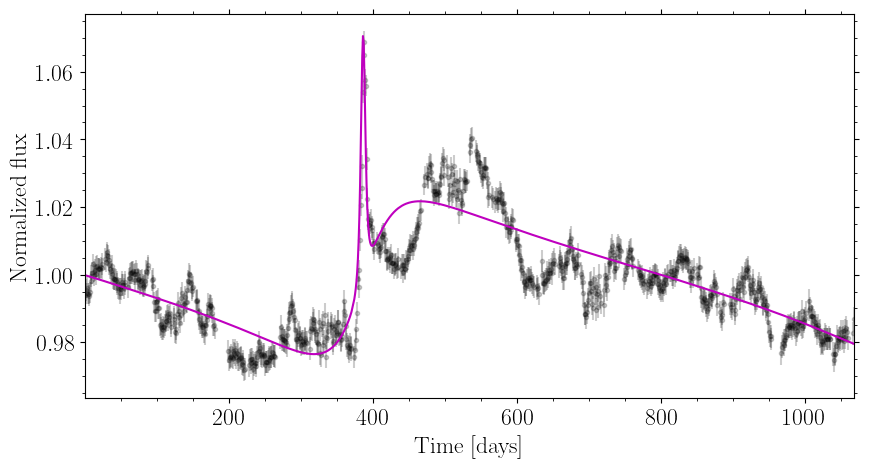

In [115]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')

# Create a binned light curve and plot
df = ut.bin_lc(df, bin_size=1)

# Convert to numpy for modelling
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Plot light curve
pt.plot_lc(df, dm, cm='m', alpha=0.2);

---
### 2.1. Model QDM light curve with DRW model

In [116]:
# Define priors
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

In [117]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors, build_kernel=bs.drw_kernel), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      1.00      0.01      1.00      0.98      1.01   7991.41      1.00
     sigma      0.02      0.00      0.02      0.01      0.02   6722.96      1.00
       tau    147.94     81.18    125.73     55.25    247.48   6333.58      1.00

Number of divergences: 0
CPU times: user 8min 47s, sys: 9.9 s, total: 8min 56s
Wall time: 1min 52s


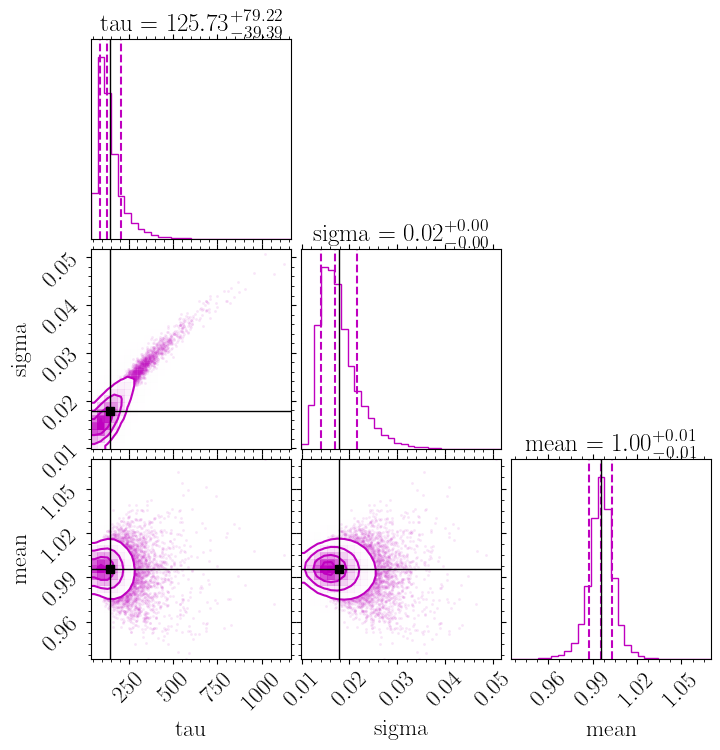

In [118]:
# Make corner plot
names  = ['tau', 'sigma', 'mean']
params = smbhb.model_params()
true_params = [1, params.sigma/1e3, params.tau]
pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');

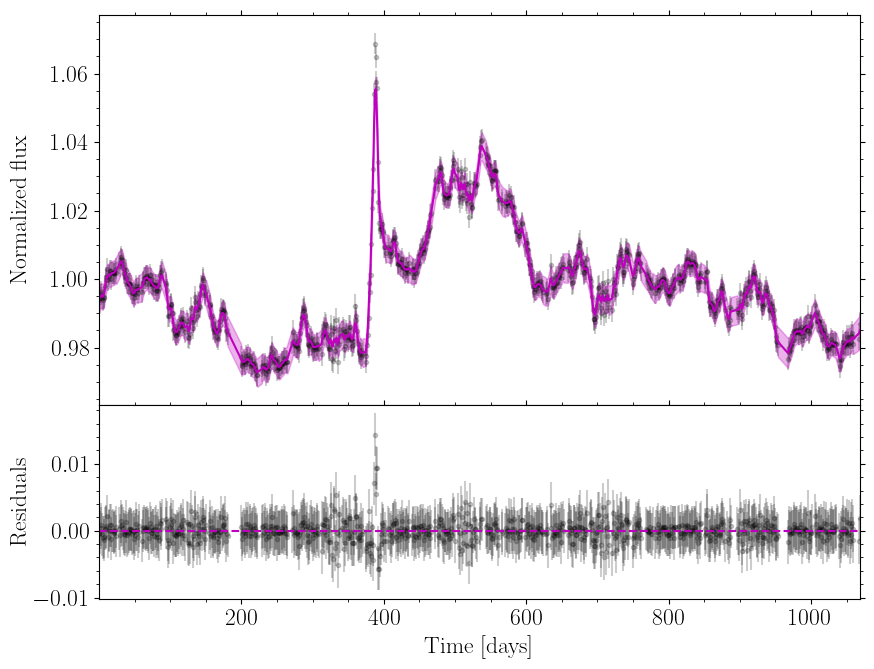

In [119]:
# Get DRW model and plot along with data
dm = bs.get_drw_lc(time, samples)
pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2);

DRW is perfectly capable of fitting the full time series

---
### 2.2. Fitting DRW + fixed SMBHB model (Spikey parameters)

In [120]:
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}
spikey_params = {
    'z'    : params.z, 
    't0'   : params.t0, 
    'P'    : params.P, 
    'i'    : params.i, 
    'e'    : params.e, 
    'w'    : params.w,
    'L'    : params.L, 
    'alpha': params.alpha, 
    'vz'   : params.vz, 
    'logM1': params.logM1, 
    'logM2': params.logM2,
}

In [121]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors | spikey_params, build_kernel=bs.drw_kernel, build_mean=bs.smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.01   7079.43      1.00
       tau     73.41     45.23     62.01     29.17    117.30   6271.39      1.00

Number of divergences: 0
CPU times: user 8min 44s, sys: 8.43 s, total: 8min 52s
Wall time: 1min 49s


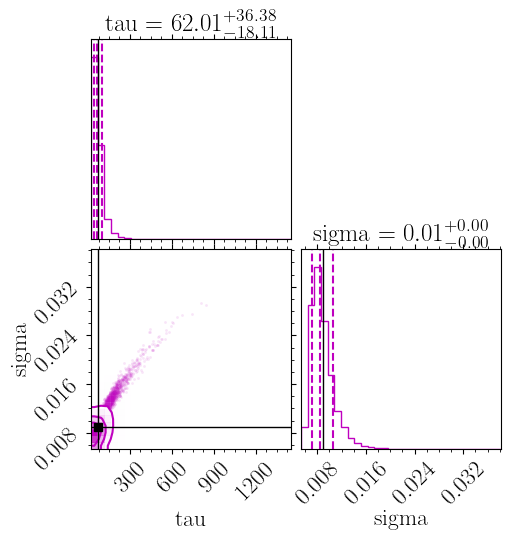

In [122]:
# Make corner plot
names  = ['tau', 'sigma']
params = smbhb.model_params()
true_params = [params.sigma/1e3, params.tau]
pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');

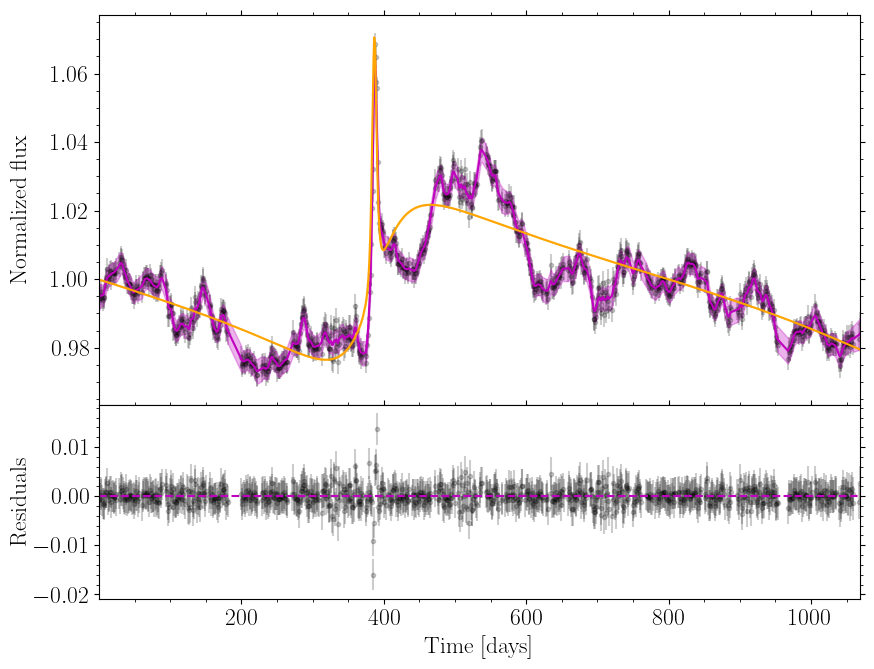

In [123]:
# Get DRW model and plot along with data
dm = bs.get_drw_lc(time, samples)
pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2);

With the SMBHB model as mean, DRW variance and time scale are smaller than in the previous case.

---
### 2.3. Fitting DRW + fixed SMBHB model (wrong parameters)

In [124]:
# Set wrong eccentricity
spikey_params_wrong = spikey_params.copy()
spikey_params_wrong['e'] = 0.0

In [125]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors | spikey_params_wrong, build_kernel=bs.drw_kernel, build_mean=bs.smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.01   7595.91      1.00
       tau     64.59     31.22     56.95     29.75     99.73   6632.53      1.00

Number of divergences: 0
CPU times: user 8min 39s, sys: 7.91 s, total: 8min 47s
Wall time: 1min 46s


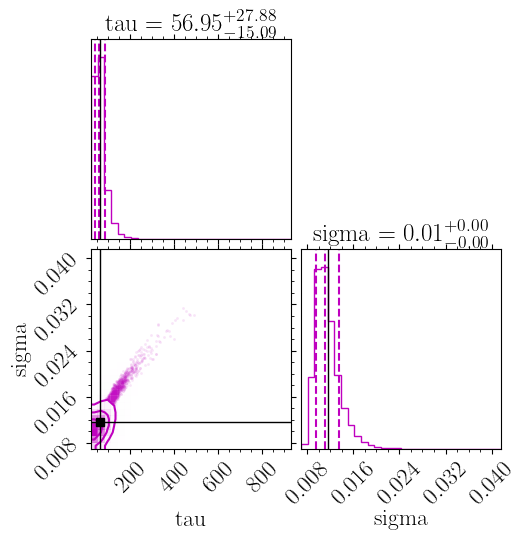

In [126]:
# Make corner plot
names  = ['tau', 'sigma']
params = smbhb.model_params()
true_params = [params.sigma/1e3, params.tau]
pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');

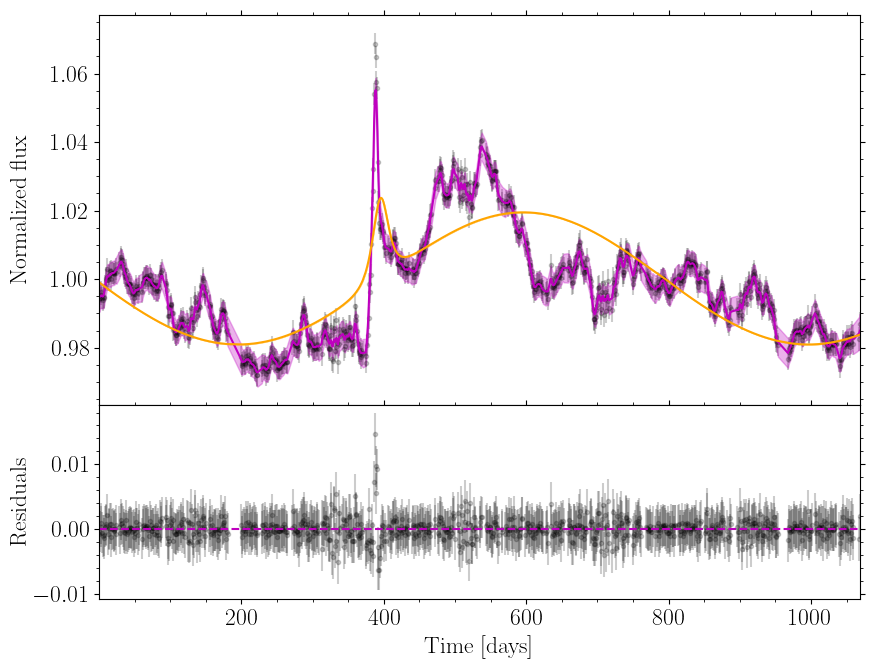

In [127]:
# Get DRW model and plot along with data
dm = bs.get_drw_lc(time, samples)
pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2);

As shown before, it does not really matter if the SMBHB model is "wrong", the DRW can compensate.

---
## 3. Modelling SMBHB model
---

### Fitting SMBHB model (uniform priors) without DRW

In [27]:
%%time

priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    'e': dist.Uniform(0.01, 0.99),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=None, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.24      0.18      0.19      0.02      0.46      2.09      5.16
         P      1.26      0.14      1.16      1.11      1.46      2.14      4.43
     alpha     -1.92      1.43     -1.96     -3.99      0.15      2.05      7.12
         e      0.32      0.18      0.37      0.01      0.52      2.01     12.32
         i     75.54     18.67     85.89     43.35     88.39      2.00     54.05
     logM1      7.83      1.87      7.13      6.00     10.88      2.00     42.19
     logM2      7.43      1.60      6.75      6.04     10.02      2.00     26.35
        t0      1.32      0.16      1.39      1.04      1.47      2.03      8.69
         w     21.81     33.50      1.65      0.06     79.79      2.02     11.00

Number of divergences: 6
CPU times: user 6min 1s, sys: 196 ms, total: 6min 1s
Wall time: 1min 37s


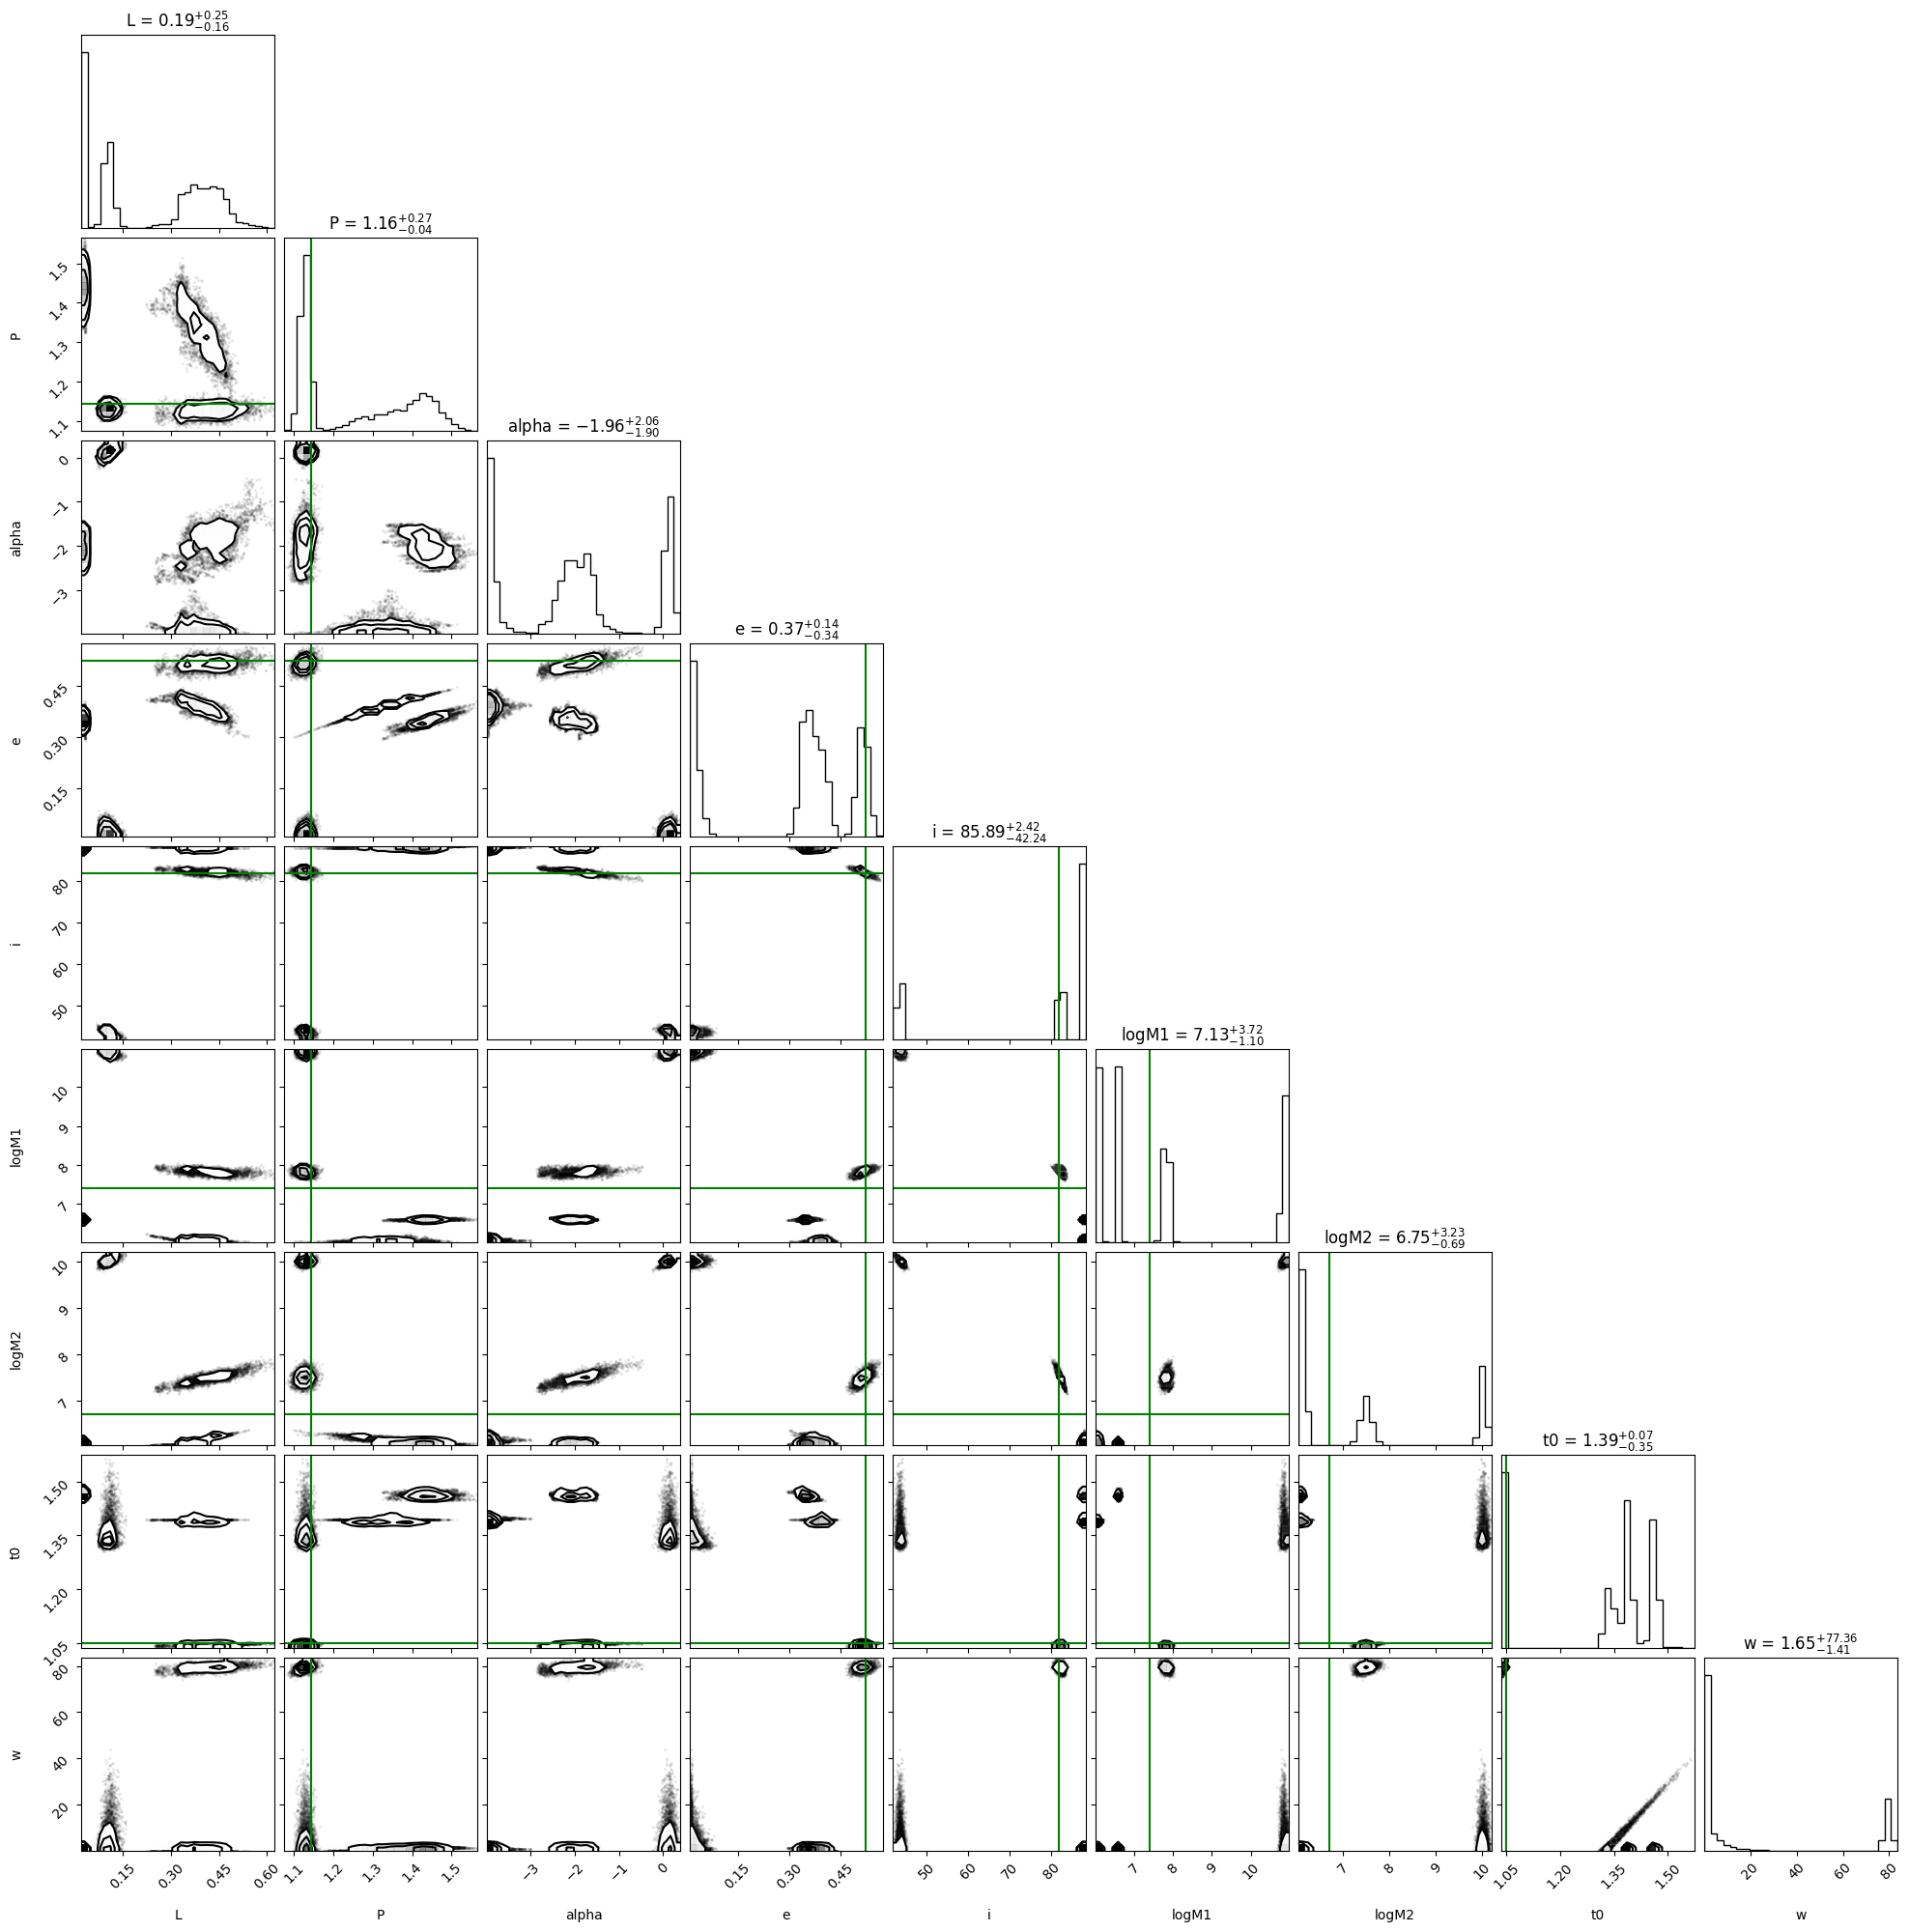

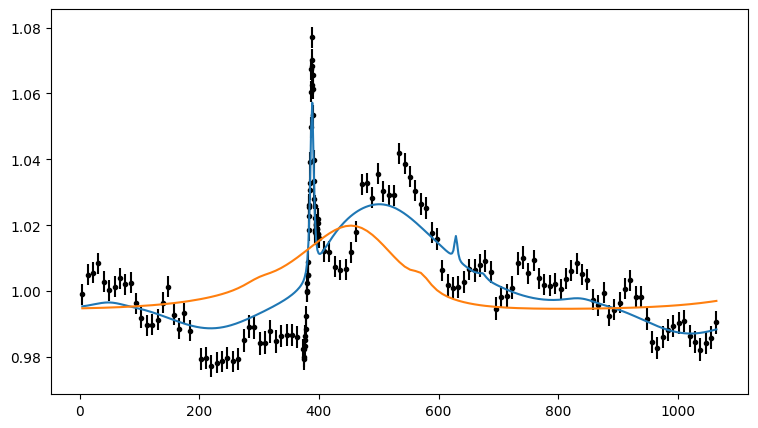

In [28]:
corner_plot(samples, true_params=spikey_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
# predictive_posterior(ax, x=time, samples=samples)
ax.plot(time_interp, samples['pred_smbhb'].mean(axis=0))

# Let's also plot the mean value
spikey_params = {
    'z': 0.918, 
    't0': samples['t0'].mean(), 
    'P': samples['P'].mean(), 
    'i': samples['i'].mean(), 
    'e': samples['e'].mean(), 
    'w': samples['w'].mean(),
    'L': samples['L'].mean(), 
    'alpha': samples['alpha'].mean(), 
    'vz': 0, 
    'logM1': samples['logM1'].mean(), 
    'logM2': samples['logM2'].mean(),
}

smbhb_partial = partial(smbhb_two_masses, **spikey_params)
sim_flux = jax.vmap(smbhb_partial)(time)
ax.plot(time, sim_flux);

### Fitting SMBHB model (uniform priors) with DRW

In [29]:
%%time

priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    'e': dist.Uniform(0.01, 0.99),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.47      0.19      0.42      0.24      0.81      5.97      1.29
         P      2.01      0.77      1.81      0.98      3.00     11.90      1.23
     alpha      2.22      1.24      2.50      0.48      3.83      2.18      3.77
         e      0.80      0.16      0.82      0.54      0.96      2.06      6.49
         i     55.21     29.26     72.19     14.80     86.35      2.07      5.28
     logM1      7.89      0.89      7.83      6.86      9.58      4.67      1.61
     logM2      8.04      1.36      8.10      6.34      9.55      2.10      5.06
     sigma      0.02      0.01      0.01      0.01      0.02      3.70      1.55
        t0      3.61      1.47      4.40      1.07      4.58      2.01     19.61
       tau    239.20    164.10    204.94     67.90    430.27     12.66      1.19
         w    163.40     98.82    143.38     51.90    328.73      2.03      7.85

Number of divergences: 113

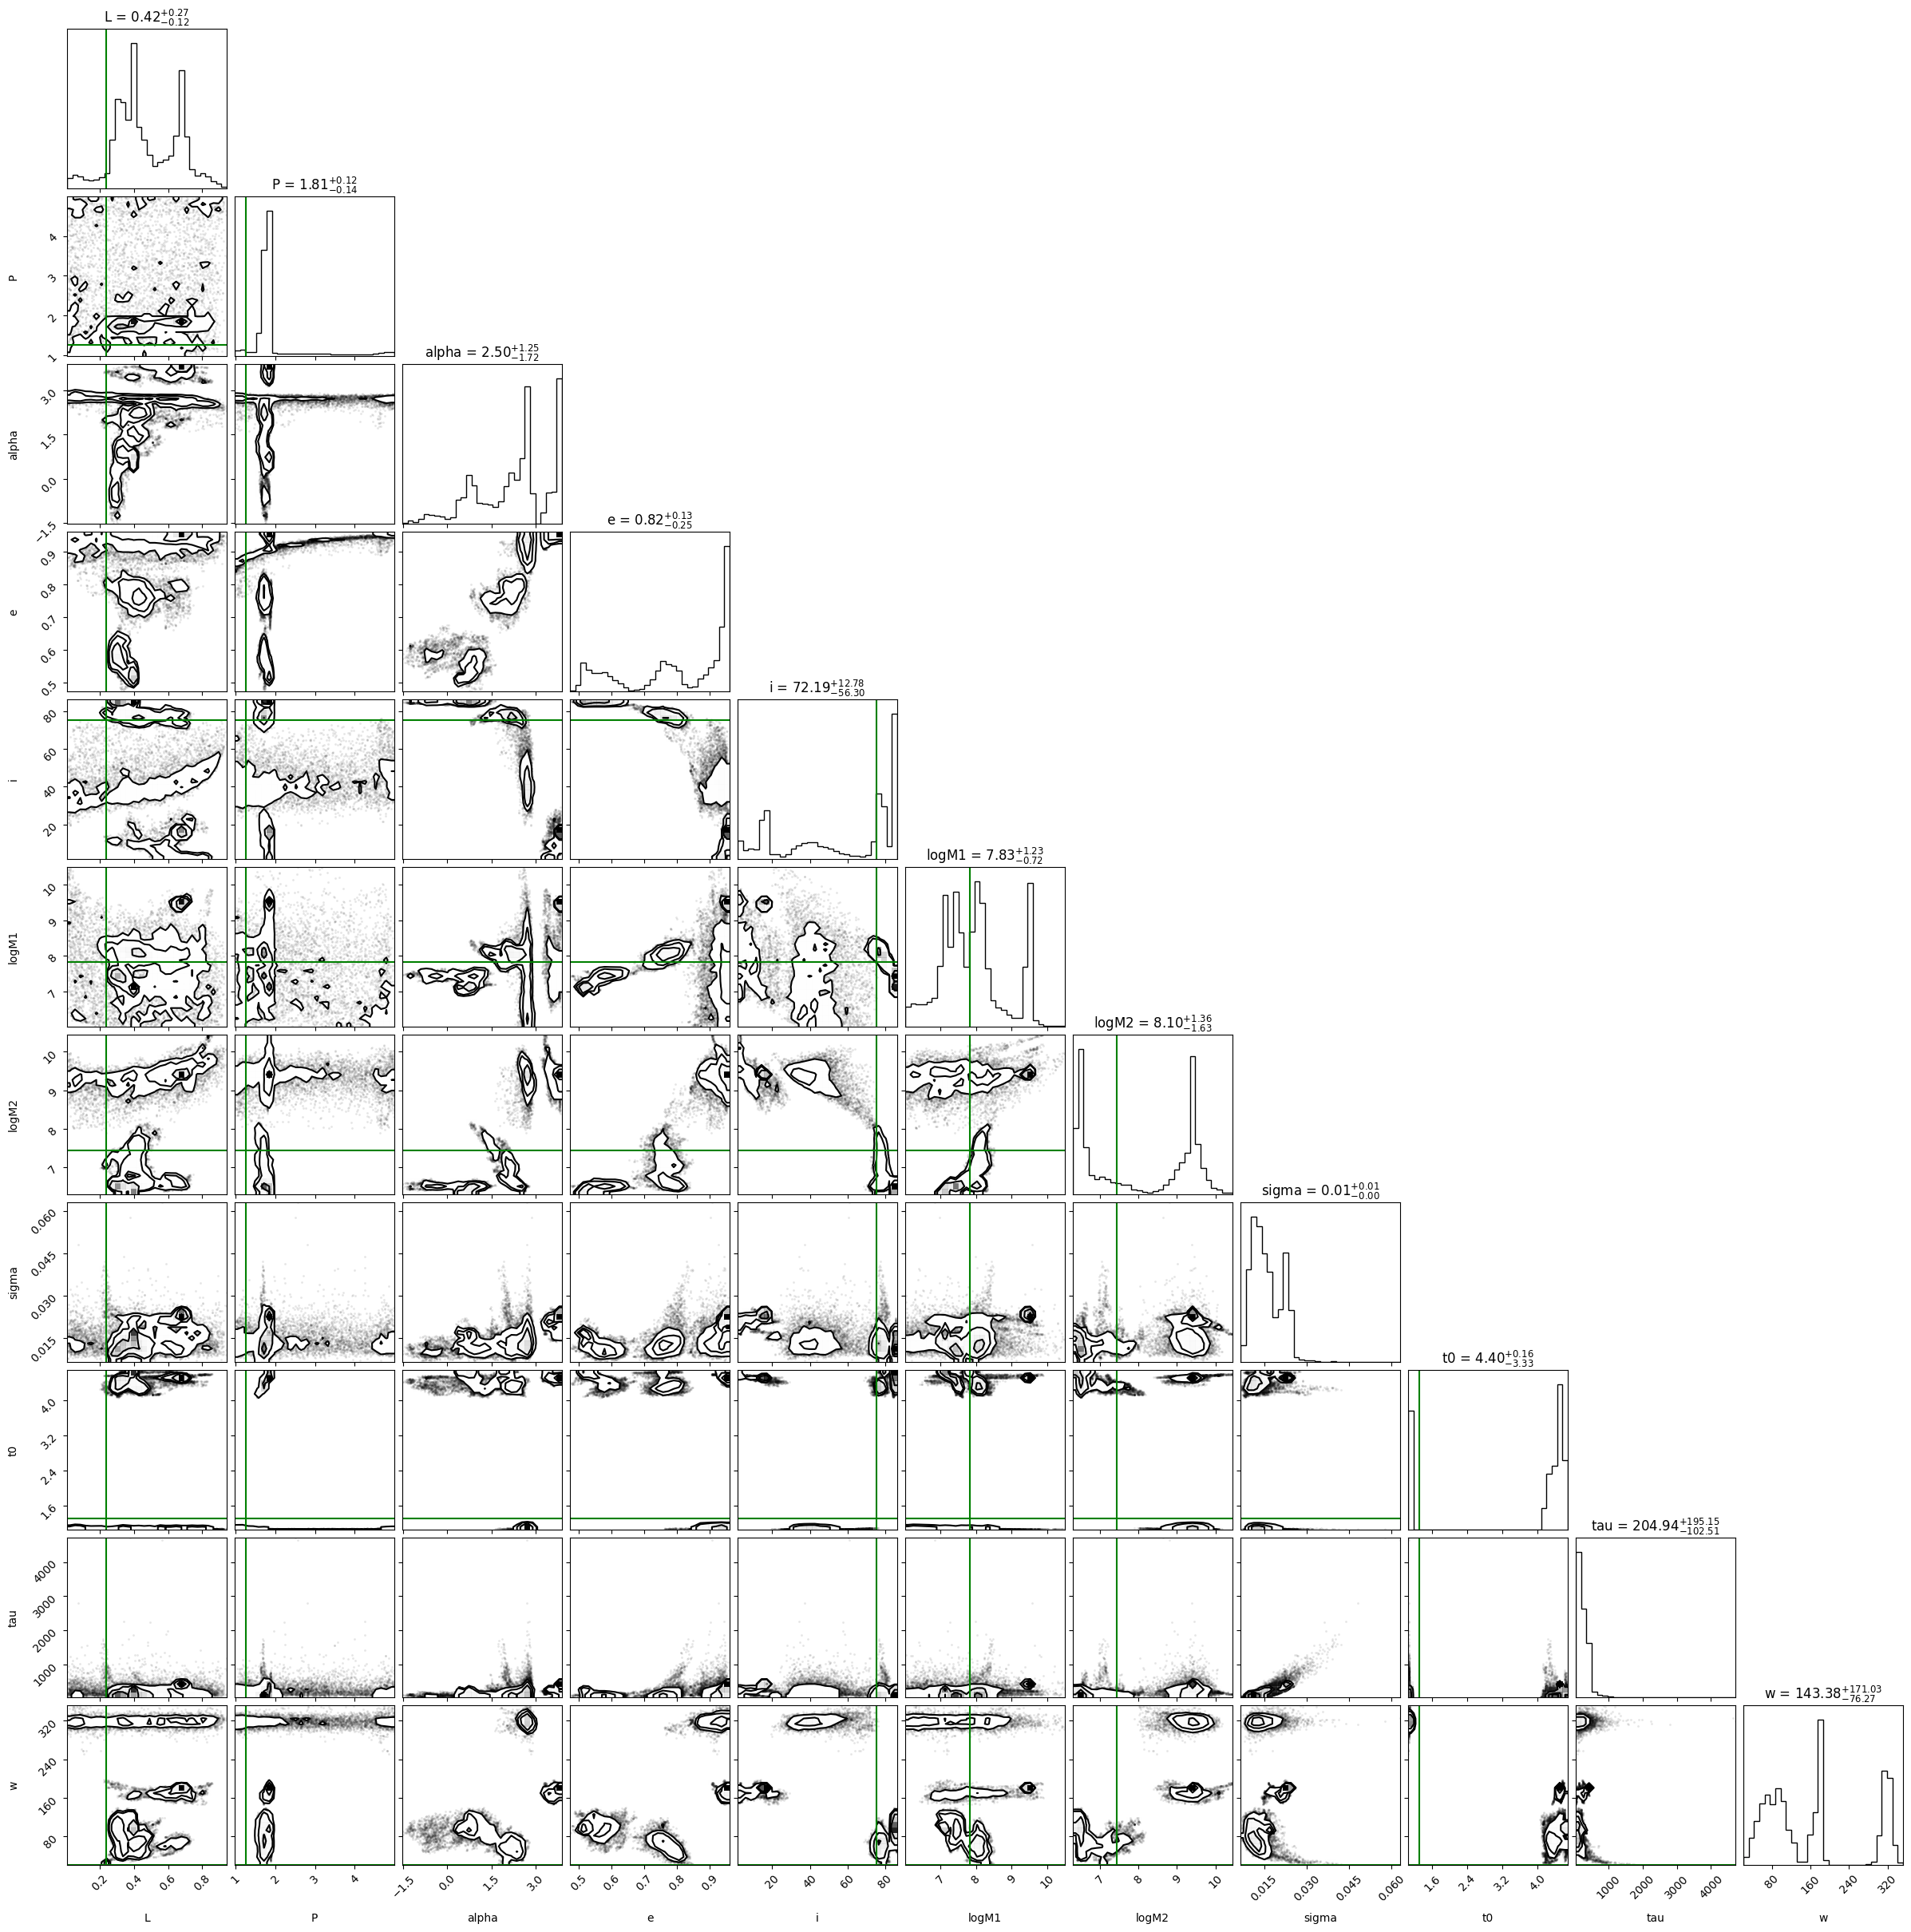

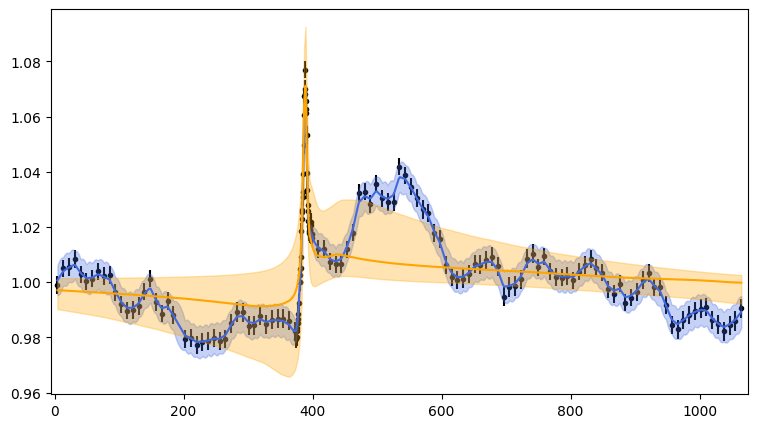

In [30]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

### Fitting SMBHB model (uniform priors) with DRW (constrained DRW)

In [31]:
%%time

priors = {
    'logM1': dist.Uniform(6, 11),
    'logM2': dist.Uniform(6, 11),
    'L': dist.Uniform(0, 1),
    'e': dist.Uniform(0, 1),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': 21,
    'sigma': 0.01,
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.46      0.28      0.41      0.02      0.89      8.59      1.20
         P      1.60      0.86      1.25      0.97      2.94      3.09      1.67
     alpha     -0.19      1.85      0.21     -3.16      2.62     10.43      1.16
         e      0.65      0.20      0.60      0.43      0.97      2.40      2.47
         i     70.33     22.45     81.88     26.81     87.32      2.32      2.64
     logM1      7.59      0.65      7.50      6.56      8.63     30.30      1.10
     logM2      7.06      0.70      7.00      6.00      7.98      6.06      1.24
        t0      1.62      0.99      1.06      0.98      3.40      2.02      9.57
         w    148.86     75.24    134.56     67.25    273.67      2.04      6.95

Number of divergences: 901
CPU times: user 10min 21s, sys: 21.3 s, total: 10min 42s
Wall time: 3min 46s


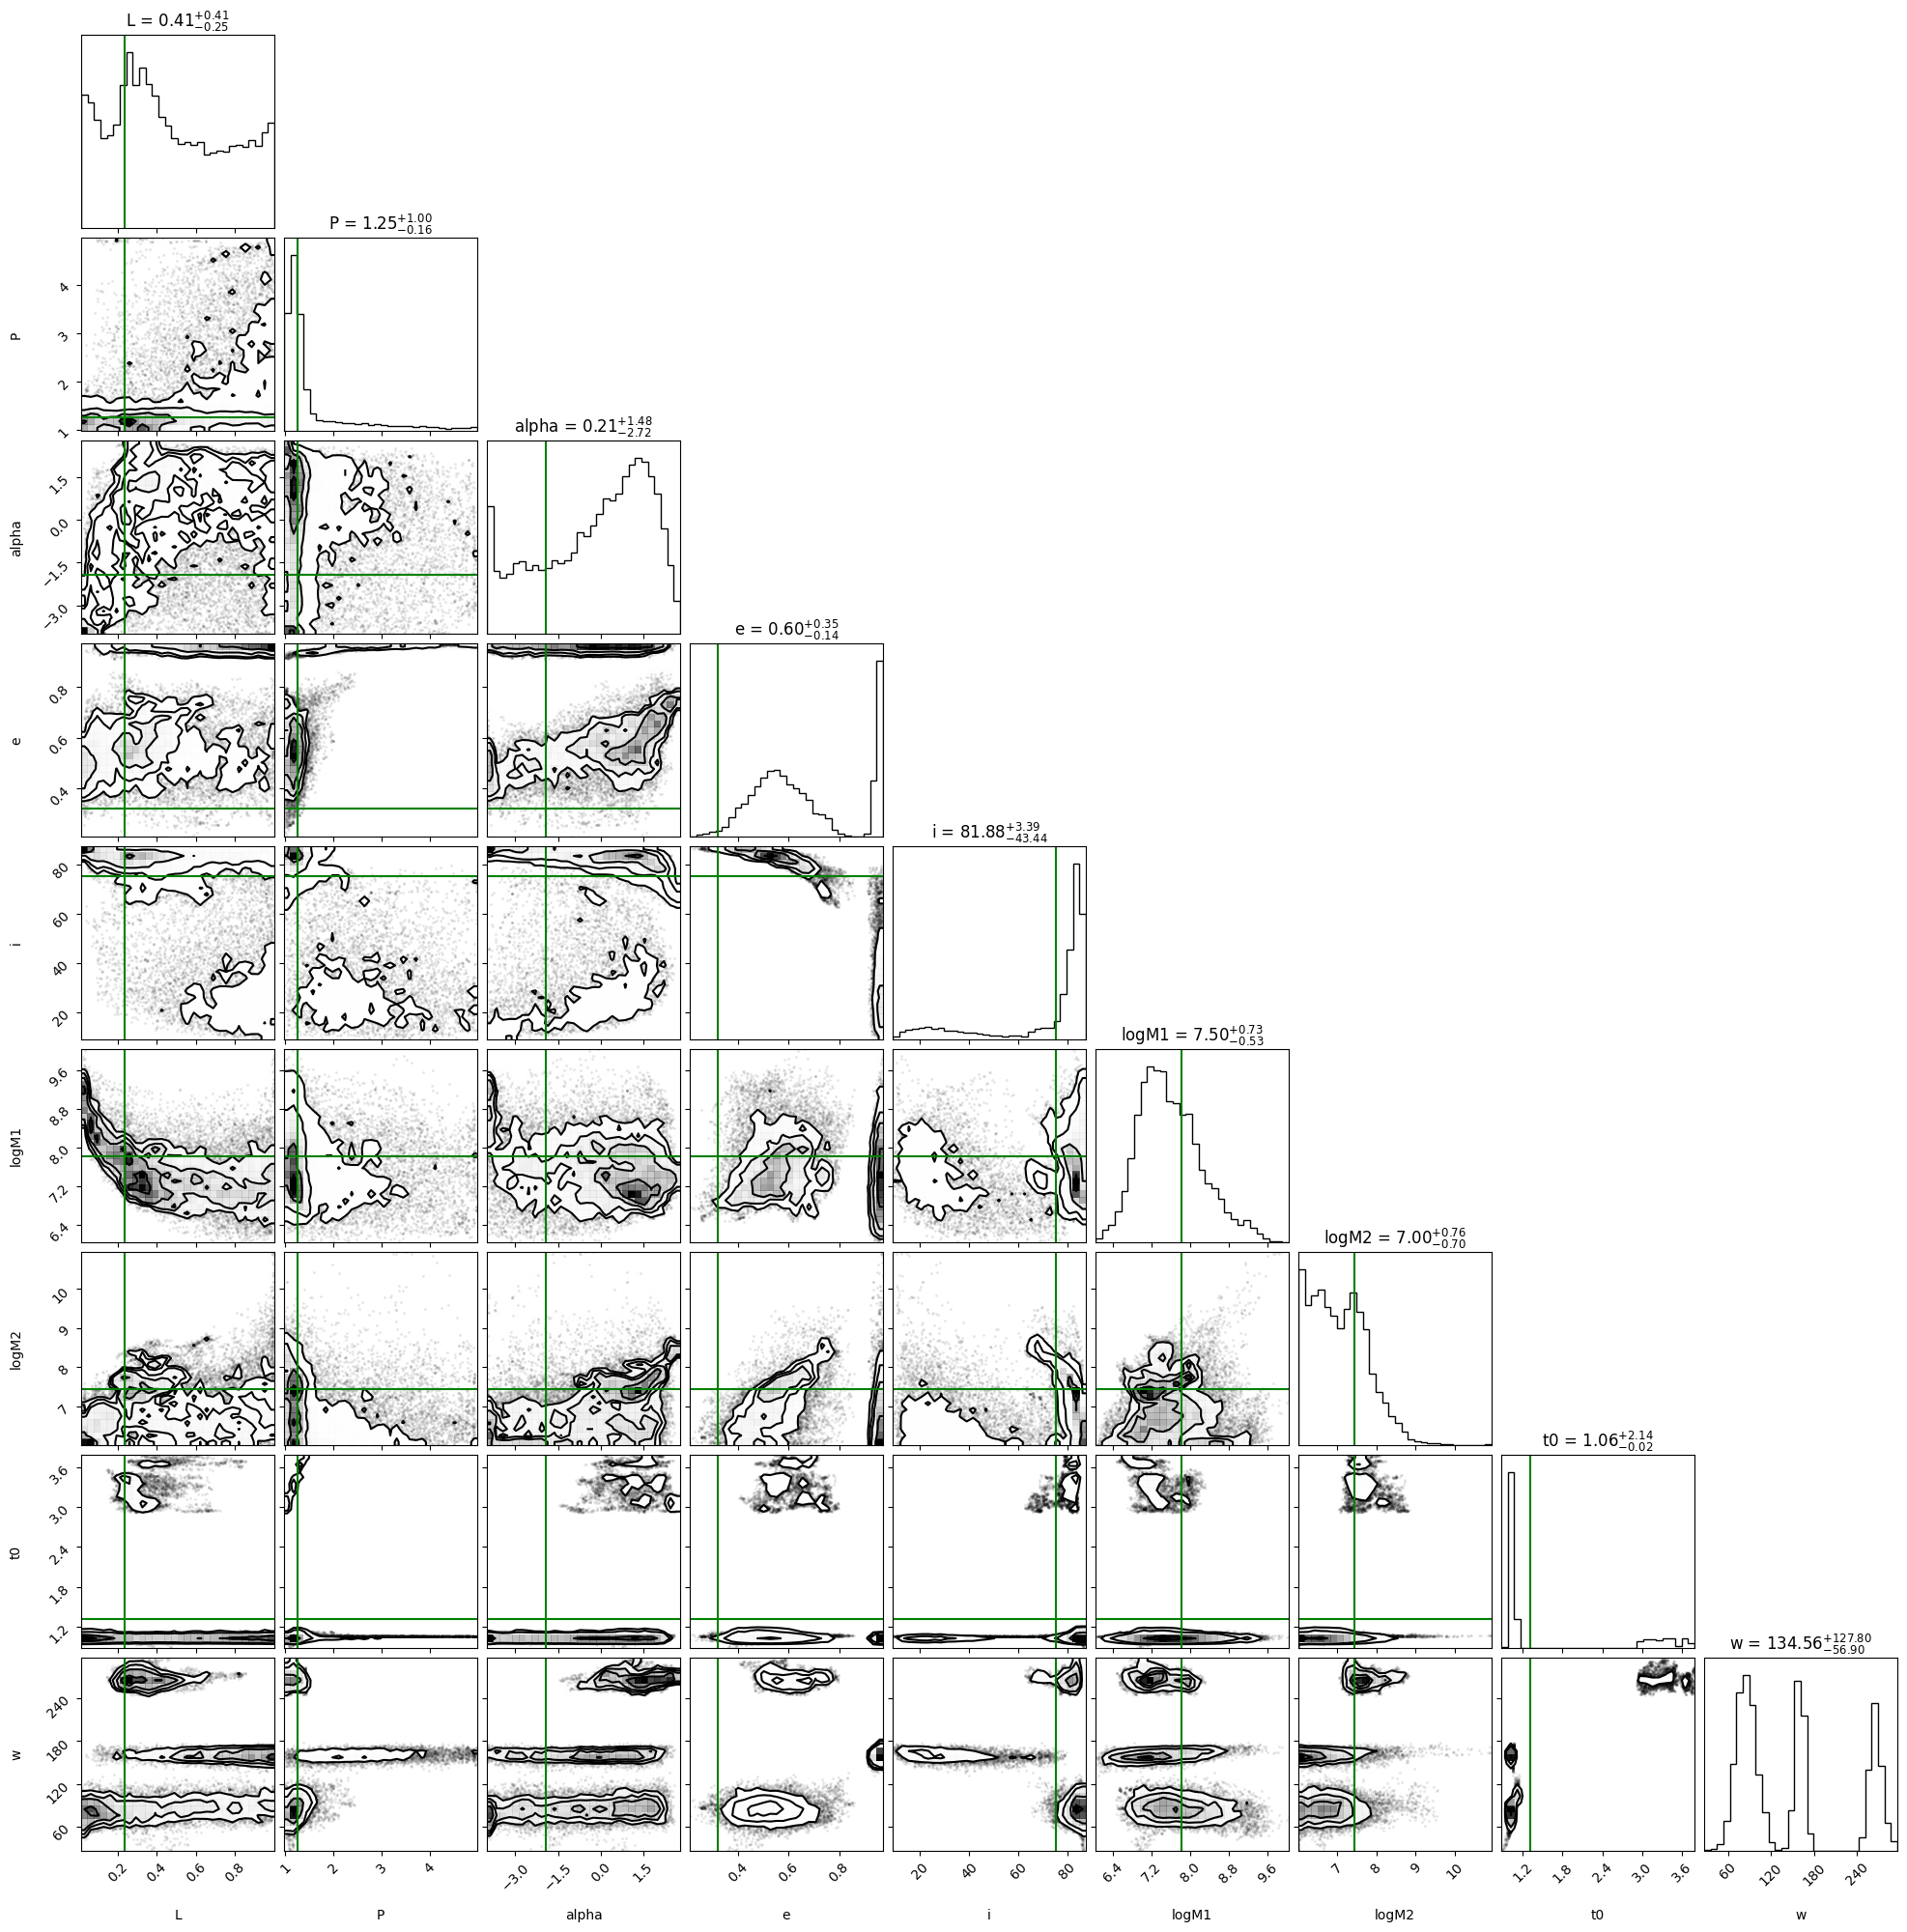

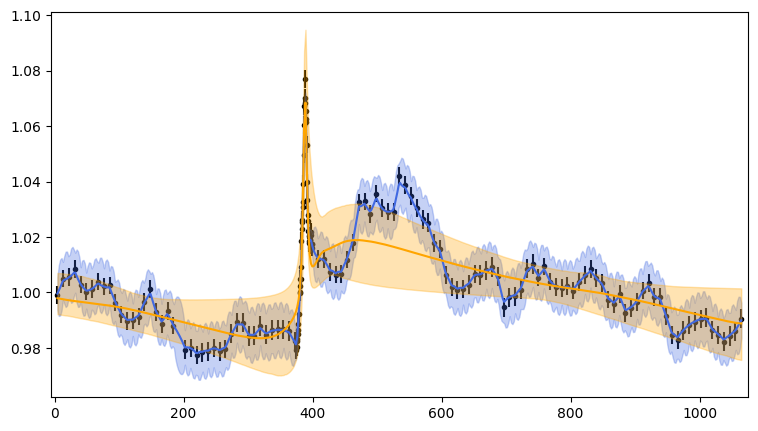

In [32]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
predictive_posterior(ax, x=time_interp, samples=samples)